# Drive mounting

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Data Extraction from Google drive which was donwloaded by the kaggle link & Verification

In [2]:
import os

# paths
drive_zip_path = '/content/drive/MyDrive/ANTLINGS_Drone_CV/dataset/archive.zip'
local_extract_path = '/content/visdrone_dataset'

# local folder
os.makedirs(local_extract_path, exist_ok=True)

# Unzip dataset
print("Extracting dataset to local Colab storage")
!unzip -q "{drive_zip_path}" -d "{local_extract_path}"
print("Extraction complete!")

Extracting dataset to local Colab storage
Extraction complete!


In [ ]:
!ls -lh "{local_extract_path}"

total 4.0K
drwxr-xr-x 6 root root 4.0K May 14 00:49 VisDrone_Dataset


# YAML Configuration & ultralytics installation

In [ ]:
!find /content/visdrone_dataset -maxdepth 2 -type d

print("\n--- Searching for YAML Files ---")
!find /content/visdrone_dataset -name "*.yaml"

True/content/visdrone_dataset
/content/visdrone_dataset/VisDrone_Dataset
/content/visdrone_dataset/VisDrone_Dataset/VisDrone2019-DET-train
/content/visdrone_dataset/VisDrone_Dataset/VisDrone2019-DET-test-challenge
/content/visdrone_dataset/VisDrone_Dataset/VisDrone2019-DET-val
/content/visdrone_dataset/VisDrone_Dataset/VisDrone2019-DET-test-dev

--- Searching for YAML Files ---
/content/visdrone_dataset/VisDrone_Dataset/visdrone.yaml


In [3]:
import yaml

old_yaml_path = '/content/visdrone_dataset/VisDrone_Dataset/visdrone.yaml'
new_yaml_path = '/content/ants_visdrone.yaml'

try:
    # the original YAML provided by the Kaggle author
    with open(old_yaml_path, 'r') as f:
        data = yaml.safe_load(f)


    data['train'] = '/content/visdrone_dataset/VisDrone_Dataset/VisDrone2019-DET-train/images'
    data['val'] = '/content/visdrone_dataset/VisDrone_Dataset/VisDrone2019-DET-val/images'
    data['test'] = '/content/visdrone_dataset/VisDrone_Dataset/VisDrone2019-DET-test-dev/images'

    # new production YAML
    with open(new_yaml_path, 'w') as f:
        yaml.dump(data, f, sort_keys=False)

    print(f"Production YAML successfully created at: {new_yaml_path}")
    print("\n--- YAML Contents ---")


    with open(new_yaml_path, 'r') as f:
        print(f.read())

except Exception as e:
    print(f"Error: {e}")

Production YAML successfully created at: /content/ants_visdrone.yaml

--- YAML Contents ---
path: ./VisDrone_Dataset
train: /content/visdrone_dataset/VisDrone_Dataset/VisDrone2019-DET-train/images
val: /content/visdrone_dataset/VisDrone_Dataset/VisDrone2019-DET-val/images
test: /content/visdrone_dataset/VisDrone_Dataset/VisDrone2019-DET-test-dev/images
nc: 10
names:
  0: pedestrian
  1: people
  2: bicycle
  3: car
  4: van
  5: truck
  6: tricycle
  7: awning-tricycle
  8: bus
  9: motor



In [6]:
!pip install ultralytics

# Visual Sanity Check  with Grid and Names

In [ ]:
import os
import glob
import random
import cv2
import matplotlib.pyplot as plt
from ultralytics.utils.plotting import Annotator

# 1. Map our class IDs to the actual names from your YAML
class_names = {
    0: "pedestrian", 1: "people", 2: "bicycle", 3: "car",
    4: "van", 5: "truck", 6: "tricycle", 7: "awning-tricycle",
    8: "bus", 9: "motor"
}

# 2. Grab 4 random images to create a grid
train_images = glob.glob('/content/visdrone_dataset/VisDrone_Dataset/VisDrone2019-DET-train/images/*.jpg')
random_images = random.sample(train_images, 4)

plt.figure(figsize=(18, 14))

# 3. Loop through and plot them
for i, img_path in enumerate(random_images):
    label_path = img_path.replace('images', 'labels').replace('.jpg', '.txt')

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    annotator = Annotator(img, line_width=2) # Thinner lines for tiny objects

    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                cls_id, x, y, w, h = map(float, line.split())

                # Fetch the string name, fallback to ID if something is weird
                cls_name = class_names.get(int(cls_id), f"Unknown({int(cls_id)})")

                # YOLO formats are normalized (0 to 1). Convert back to pixels.
                ih, iw, _ = img.shape
                x1 = int((x - w/2) * iw)
                y1 = int((y - h/2) * ih)
                x2 = int((x + w/2) * iw)
                y2 = int((y + h/2) * ih)

                # Plot with the actual name
                annotator.box_label([x1, y1, x2, y2], label=cls_name)

    plt.subplot(2, 2, i+1)
    plt.imshow(annotator.result())
    plt.axis('off')
    plt.title(f"Sample {i+1}: {os.path.basename(img_path)}")

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

# Initializing Training

In [ ]:
from ultralytics import YOLO

# Load the YOLOv26 Medium weights for maximum accuracy
model = YOLO('yolo26m.pt')

# training loop
results = model.train(
    data='/content/ants_visdrone.yaml',
    epochs=50,                           # 50 is a solid baseline for VisDrone
    imgsz=640,                           # Standard resolution
    batch=8,                             #  8 to prevent T4 OOM errors
    device=0,                            # to use the T4 GPU
    project='/content/drive/MyDrive/ANTLINGS_Drone_CV/runs', # Save straight to Drive
    name='yolo26m_visdrone_final',       # Folder name for this high-accuracy run
    save=True,                           # Save weights securely
    cache=False                          # False saves system RAM
)

Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/ants_visdrone.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26m_visdrone_final-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, 

In [7]:
from ultralytics import YOLO

last_weights = '/content/drive/MyDrive/ANTLINGS_Drone_CV/runs/yolo26m_visdrone_final-2/weights/last.pt'

model = YOLO(last_weights)
model.train(resume=True)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/ants_visdrone.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=6

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b0ec4c42ae0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0

#  test


image 1/1 /content/visdrone_dataset/VisDrone_Dataset/VisDrone2019-DET-val/images/0000242_05059_d_0000015.jpg: 384x640 1 people, 1 bicycle, 12 cars, 3 motors, 73.0ms
Speed: 2.3ms preprocess, 73.0ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)


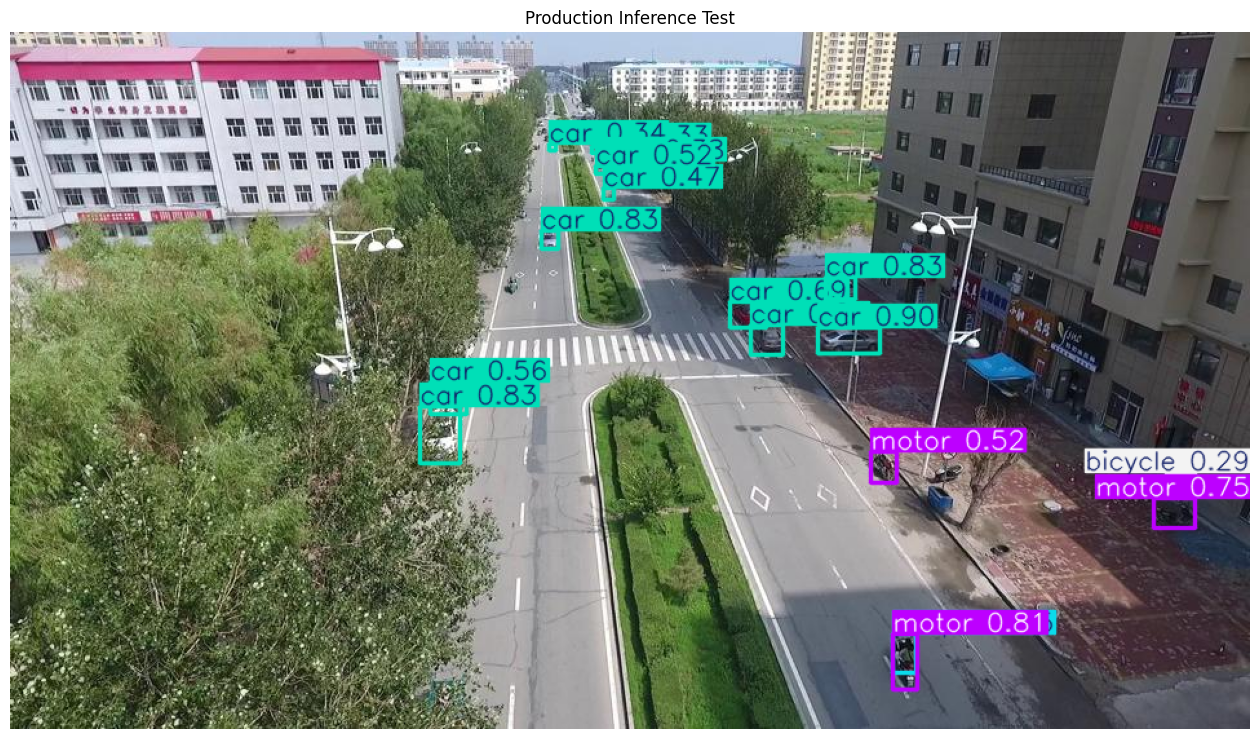

In [8]:
from ultralytics import YOLO
import glob
import random
import cv2
import matplotlib.pyplot as plt


model = YOLO('/content/drive/MyDrive/ANTLINGS_Drone_CV/runs/yolo26m_visdrone_final-2/weights/best.pt')

# 2. Pick a random test image from the VisDrone validation set
val_images = glob.glob('/content/visdrone_dataset/VisDrone_Dataset/VisDrone2019-DET-val/images/*.jpg')
test_img = random.choice(val_images)

# 3. Run Inference (Prediction)
# conf=0.25 means "only show boxes you are at least 25% confident about"
results = model.predict(source=test_img, conf=0.25, save=False)

# 4. Visualize the result
res_plotted = results[0].plot(line_width=2) # Draw the boxes
res_plotted = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(16, 12))
plt.imshow(res_plotted)
plt.axis('off')
plt.title("Production Inference Test")
plt.show()

In [12]:
import cv2
import os
from ultralytics import YOLO
from tqdm import tqdm

# 1. Configuration
MODEL_PATH = '/content/drive/MyDrive/ANTLINGS_Drone_CV/runs/yolo26m_visdrone_final-2/weights/best.pt'
INPUT_VIDEO = '/content/drive/MyDrive/ANTLINGS_Drone_CV/dataset/Drone Street Traffic, New York City.mp4'
OUTPUT_DIR = '/content/drive/MyDrive/ANTLINGS_Drone_CV/outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)
OUTPUT_PATH = os.path.join(OUTPUT_DIR, 'result_test_drone.mp4')

# 2. Load the production-grade YOLOv26m model
model = YOLO(MODEL_PATH)

# 3. Initialize Video Capture
cap = cv2.VideoCapture(INPUT_VIDEO)

# --- THE FIX IS HERE ---
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
# -----------------------

# 4. Initialize Video Writer
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(OUTPUT_PATH, fourcc, fps, (width, height))

print(f"🚀 Starting Inference on {total_frames} frames at {width}x{height} resolution...")

# 5. The Custom OpenCV Loop
with tqdm(total=total_frames) as pbar:
    while cap.isOpened():
        success, frame = cap.read()
        if not success:
            break

        # Run inference on the current frame
        results = model.predict(frame, conf=0.25, verbose=False)

        # Draw results on the frame
        annotated_frame = results[0].plot(
            line_width=1,   # Razor-thin bounding boxes
            font_size=1,    # Absolute minimum font size
            conf=False      # Hide the '0.88' numbers to save pixel space
        )

        # Write the frame to the output video
        out.write(annotated_frame)

        pbar.update(1)

# 6. Release resources
cap.release()
out.release()
print(f"\n✅ Processing complete! Video saved to: {OUTPUT_PATH}")

🚀 Starting Inference on 502 frames at 360x640 resolution...


100%|██████████| 502/502 [00:13<00:00, 37.79it/s]


✅ Processing complete! Video saved to: /content/drive/MyDrive/ANTLINGS_Drone_CV/outputs/result_test_drone.mp4


# Implementing SAHI

In [2]:
!pip install sahi

In [5]:
import cv2
import os
import numpy as np
from tqdm import tqdm
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
from sahi.utils.cv import visualize_object_predictions

#  Configuration
MODEL_PATH = '/content/drive/MyDrive/ANTLINGS_Drone_CV/runs/yolo26m_visdrone_final-2/weights/best.pt'
INPUT_VIDEO = '/content/drive/MyDrive/ANTLINGS_Drone_CV/dataset/Drone Street Traffic, New York City.mp4'
OUTPUT_DIR = '/content/drive/MyDrive/ANTLINGS_Drone_CV/outputs'
OUTPUT_PATH = os.path.join(OUTPUT_DIR, 'result_sahi_drone.mp4')

#  Load the Model inside the SAHI Wrapper
print("Loading model into SAHI...")
detection_model = AutoDetectionModel.from_pretrained(
    model_type='yolov8',
    model_path=MODEL_PATH,
    confidence_threshold=0.25,
    device="cuda:0" #  GPU
)

# Video Setup
cap = cv2.VideoCapture(INPUT_VIDEO)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(OUTPUT_PATH, fourcc, fps, (width, height))

print(f"🚀 Starting SAHI Inference on {total_frames} frames...")

#  SAHI Slicing Loop
with tqdm(total=total_frames) as pbar:
    while cap.isOpened():
        success, frame = cap.read()
        if not success:
            break

        # OpenCV uses BGR, SAHI expects RGB. Convert it.
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)


        #  slice the image into 640x640 patches with 20% overlap
        result = get_sliced_prediction(
            rgb_frame,
            detection_model,
            slice_height=640,
            slice_width=640,
            overlap_height_ratio=0.2,
            overlap_width_ratio=0.2,
            verbose=0
        )

        #  visualizer
        annotated_frame = visualize_object_predictions(
            image=np.ascontiguousarray(frame),
            object_prediction_list=result.object_prediction_list,
            rect_th=1,
            text_size=0.3,
            text_th=1
        )

        out.write(annotated_frame['image'])
        pbar.update(1)

cap.release()
out.release()
print(f"\n✅ SAHI Processing complete! Video saved to: {OUTPUT_PATH}")

Loading model into SAHI...
🚀 Starting SAHI Inference on 502 frames...


100%|██████████| 502/502 [00:22<00:00, 22.66it/s]


✅ SAHI Processing complete! Video saved to: /content/drive/MyDrive/ANTLINGS_Drone_CV/outputs/result_sahi_drone.mp4


# Multi-Object Tracking

In [8]:
import cv2
import os
from ultralytics import YOLO
from tqdm import tqdm

# 1. Configuration
MODEL_PATH = '/content/drive/MyDrive/ANTLINGS_Drone_CV/runs/yolo26m_visdrone_final-2/weights/best.pt'
INPUT_VIDEO = '/content/drive/MyDrive/ANTLINGS_Drone_CV/dataset/Drone Street Traffic, New York City.mp4'
OUTPUT_DIR = '/content/drive/MyDrive/ANTLINGS_Drone_CV/outputs'
OUTPUT_PATH = os.path.join(OUTPUT_DIR, 'result_tracking_drone.mp4')

# 2. Load the Model
model = YOLO(MODEL_PATH)
cap = cv2.VideoCapture(INPUT_VIDEO)

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(OUTPUT_PATH, fourcc, fps, (width, height))

print(f"🚀 Starting ByteTrack Inference on {total_frames} frames...")

# 3. The Tracking Loop
with tqdm(total=total_frames) as pbar:
    while cap.isOpened():
        success, frame = cap.read()
        if not success:
            break

        # --- THE BYTE-TRACK UPGRADE ---
        # persist=True: Tells the model to remember objects across frames
        # tracker="bytetrack.yaml": Uses the ByteTrack algorithm optimized for low-confidence tiny objects
        results = model.track(
            frame,
            persist=True,
            tracker="bytetrack.yaml",
            conf=0.25,
            verbose=False
        )

        # Draw results. We keep the font small, but this time we will see the Tracking IDs!
        annotated_frame = results[0].plot(line_width=1, font_size=1)

        out.write(annotated_frame)
        pbar.update(1)

cap.release()
out.release()
print(f"\n✅ Tracking complete! Video saved to: {OUTPUT_PATH}")

🚀 Starting ByteTrack Inference on 502 frames...


  0%|          | 0/502 [00:00<?, ?it/s]

requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 210ms
Prepared 1 package in 21ms
Installed 1 package in 4ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.7s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect



100%|██████████| 502/502 [00:19<00:00, 25.66it/s]


✅ Tracking complete! Video saved to: /content/drive/MyDrive/ANTLINGS_Drone_CV/outputs/result_tracking_drone.mp4


# Human & Vehicle Counting

In [18]:
import cv2
import os
from ultralytics.solutions import object_counter
from tqdm import tqdm

MODEL_PATH = '/content/drive/MyDrive/ANTLINGS_Drone_CV/runs/yolo26m_visdrone_final-2/weights/best.pt'
INPUT_VIDEO = '/content/drive/MyDrive/ANTLINGS_Drone_CV/dataset/Drone Street Traffic, New York City.mp4'
OUTPUT_DIR = '/content/drive/MyDrive/ANTLINGS_Drone_CV/outputs'
OUTPUT_PATH = os.path.join(OUTPUT_DIR, 'result_counting_drone.mp4')

cap = cv2.VideoCapture(INPUT_VIDEO)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(OUTPUT_PATH, fourcc, fps, (width, height))

margin = 2
region_points = [
    (margin, margin),
    (width - margin, margin),
    (width - margin, height - margin),
    (margin, height - margin)
]

counter = object_counter.ObjectCounter(
    show=False,
    region=region_points,
    line_width=2,
    model=MODEL_PATH,
    tracker="bytetrack.yaml",
    conf=0.25
)

print(f"Processing {total_frames} frames...")

with tqdm(total=total_frames) as pbar:
    while cap.isOpened():
        success, frame = cap.read()
        if not success:
            break

        results = counter(frame)
        out.write(results.plot_im)

        pbar.update(1)

cap.release()
out.release()
print(f"Done. Saved to: {OUTPUT_PATH}")

Ultralytics Solutions: ✅ {'source': None, 'model': '/content/drive/MyDrive/ANTLINGS_Drone_CV/runs/yolo26m_visdrone_final-2/weights/best.pt', 'classes': None, 'show_conf': True, 'show_labels': True, 'region': [(2, 2), (358, 2), (358, 638), (2, 638)], 'colormap': 21, 'show_in': True, 'show_out': True, 'up_angle': 145.0, 'down_angle': 90, 'kpts': [6, 8, 10], 'analytics_type': 'line', 'figsize': (12.8, 7.2), 'blur_ratio': 0.5, 'vision_point': (20, 20), 'crop_dir': 'cropped-detections', 'json_file': None, 'line_width': 2, 'records': 5, 'fps': 30.0, 'max_hist': 5, 'meter_per_pixel': 0.05, 'max_speed': 120, 'show': False, 'iou': 0.7, 'conf': 0.25, 'device': None, 'max_det': 300, 'half': False, 'tracker': 'bytetrack.yaml', 'verbose': True, 'data': 'images'}
Processing 502 frames...


  0%|          | 0/502 [00:00<?, ?it/s]

0: 640x360 4.3ms, 23 car, 8 pedestrian, 2 truck
Speed: 331.3ms track, 4.3ms solution per image at shape (1, 3, 640, 360)



  0%|          | 1/502 [00:00<02:55,  2.85it/s]

1: 640x360 6.1ms, 20 car, 6 pedestrian, 1 truck
Speed: 32.2ms track, 6.1ms solution per image at shape (1, 3, 640, 360)

2: 640x360 2.7ms, 20 car, 4 pedestrian, 1 truck
Speed: 32.1ms track, 2.7ms solution per image at shape (1, 3, 640, 360)

3: 640x360 4.0ms, 22 car, 6 pedestrian, 1 truck
Speed: 33.2ms track, 4.0ms solution per image at shape (1, 3, 640, 360)



...

499: 640x360 10.7ms, 33 car, 16 pedestrian, 3 bus
Speed: 52.1ms track, 10.7ms solution per image at shape (1, 3, 640, 360)

500: 640x360 11.2ms, 33 car, 16 pedestrian, 3 bus, 1 truck
Speed: 46.7ms track, 11.2ms solution per image at shape (1, 3, 640, 360)



100%|█████████▉| 501/502 [00:25<00:00, 14.12it/s]

501: 640x360 12.7ms, 34 car, 18 pedestrian, 2 bus
Speed: 49.4ms track, 12.7ms solution per image at shape (1, 3, 640, 360)



100%|██████████| 502/502 [00:25<00:00, 19.66it/s]

Done. Saved to: /content/drive/MyDrive/ANTLINGS_Drone_CV/outputs/result_counting_drone.mp4
